# ISO 20414:2020 — Test 14: Group Behaviour

A room of size 15 m x 20 m with a 1 m exit (ISO 20414:2020 Table 16). Two groups of occupants of size 5,10 in Zone 1 and Zone 2, respectively. 4 out of 5 occupants Group 1 has walking speed of 1,55 m/s whereas the fifth one has 0,8 m/s. The group of 10 uniformly occupying Zone 2 has a smaller walking speed of 0,5 m/s. The occupants in Zone 1 have to reach the exit of the room. The expected result is that the occupants of Group 1 will reach the exit together (i.e. the times for occupants of Group 1 to reach the exit should not differ more than 10s)

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 11 June 2026, 11:34 CEST


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pedpy
from shapely.geometry import Point, Polygon

from jupedsim_scenarios import load_scenario, run_scenario, run_sweep

In [3]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

## Load and Run

In [4]:
%%capture 
SCENARIO_ZIP = Path("scenario_files") / "Iso-14-group-behaviour.zip"
scenario = load_scenario(str(SCENARIO_ZIP))
result = run_scenario(scenario, seed=4)

In [5]:
print(scenario.summary())
walkable = scenario.walkable_polygon
df = result.trajectory_dataframe()

Scenario: /Users/elif/Desktop/HiWi/jupedsim-web-community/standards/iso/scenario_files/Iso-14-group-behaviour.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      300s
  Exits:         1
  Distributions: 2
  Stages:        0
  Zones:         0
  Journeys:      0
  Agents:        ~15
    jps-distributions_0: 5 agents
    jps-distributions_1: 10 agents


## Exit Times of Group 1

In [6]:
group_1_id = [1,2,3,4,5]
df_group_1=df[df["id"].isin(group_1_id)].sort_values(["id","frame"])

EXIT_Y = 1.0
exit_rows = []
for agent_id, sub in df_group_1.groupby("id"):
    crossed = sub[sub["y"]<= EXIT_Y] 
    if len(crossed):
        exit_time = crossed.iloc[0]["frame"] / result.frame_rate
        exit_rows.append({
            "id": int(agent_id),
            "exit_time_s": exit_time
        })
exit_times= pd.DataFrame(exit_rows).sort_values("exit_time_s")
exit_times


,id,exit_time_s
2,3,35.0
0,1,35.1
3,4,36.5
1,2,37.5
4,5,37.8


## Plot Trajectories

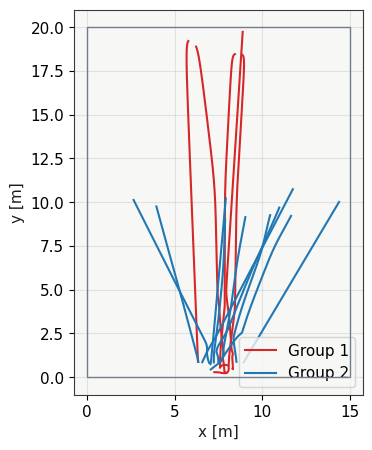

In [7]:
df_plot = df[["id", "frame", "x", "y"]].copy()
df_plot["is_group_1"] = df_plot["id"].isin(group_1_id)
traj = pedpy.TrajectoryData(df_plot[['id', 'frame', 'x', 'y']].copy(), frame_rate=result.frame_rate)
wa = pedpy.WalkableArea(walkable)
fig, ax = plt.subplots()

pedpy.plot_walkable_area(walkable_area=wa, axes=ax)

for agent_id, sub in df_plot.sort_values(["id", "frame"]).groupby("id"):
    color = "tab:red" if agent_id in group_1_id else "tab:blue"
    ax.plot(sub["x"],sub["y"],color=color)
ax.plot([], [], color="tab:red", label="Group 1")
ax.plot([], [], color="tab:blue", label="Group 2")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal", adjustable="box")
ax.legend()
plt.show()

## Acceptance 

In [8]:
exit_diff = exit_times["exit_time_s"].max() - exit_times["exit_time_s"].min()
MAX_GROUP_EXIT_DIFF_S=10.0
assert exit_diff <= MAX_GROUP_EXIT_DIFF_S
print(f'evacuation time={result.evacuation_time:.2f}s')
result.cleanup()

evacuation time=39.04s
